
# Model Analysis & Selection
## Objective:
- Load and analyze model evaluation results from `2_model_training.ipynb`.
- Identify potentially overfitted models.
- Evaluate stability across folds.
- Rank and select the most promising preprocessing + model combinations.

In [3]:
# Import libraries =====================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load results =========================================================
results_path = os.path.join('..', 'results', 'model_evaluation_results.csv')
output_dir = os.path.join('..', 'results', 'analysis')
os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(results_path):
    raise FileNotFoundError("Model evaluation file not found. Make sure to run 2_model_training.ipynb first.")

results_df = pd.read_csv(results_path)

print("✅ Results loaded successfully.")



✅ Results loaded successfully.


### 1. Basic Data Overview

In [6]:
print("Total number of evaluated combinations:", len(results_df))
display(results_df.head())
print("\n📊 Dataset statistics per (file, model):")
summary_df = results_df.groupby(['Processed_File', 'Model']).agg(
    mean_auc=('ROC AUC', 'mean'),
    std_auc=('ROC AUC', 'std'),
    mean_f1=('F1', 'mean'),
    std_f1=('F1', 'std'),
    count=('Fold', 'count')
).reset_index().sort_values(by='mean_auc', ascending=False)

display(summary_df.head(15))

Total number of evaluated combinations: 610


,Processed_File,Model,Fold,ROC AUC,Accuracy,Precision,Recall,F1
0,Data_drop_na.pkl,LightGBM,0,0.677193,0.982759,0.0,0.0,0.0
1,Data_drop_na.pkl,LightGBM,1,0.691228,0.982759,0.0,0.0,0.0
2,Data_drop_na.pkl,LightGBM,2,0.527018,0.982759,0.0,0.0,0.0
3,Data_drop_na.pkl,LightGBM,3,0.569123,0.982759,0.0,0.0,0.0
4,Data_drop_na.pkl,LightGBM,4,0.425352,0.982699,0.0,0.0,0.0



📊 Dataset statistics per (file, model):


,Processed_File,Model,mean_auc,std_auc,mean_f1,std_f1,count
4,Data_drop_na_balanced_smote.pkl,CatBoost,0.999943,0.000066,0.996117,0.004029,5
5,Data_drop_na_balanced_smote.pkl,LightGBM,0.999399,0.000949,0.993270,0.006587,5
7,Data_drop_na_balanced_smote.pkl,MLP,0.997507,0.001723,0.984782,0.003857,5
28,Data_iterative_imputed_balanced_smote.pkl,CatBoost,0.994899,0.000836,0.985448,0.001110,5
29,Data_iterative_imputed_balanced_smote.pkl,LightGBM,0.994118,0.001286,0.983921,0.001159,5
31,Data_iterative_imputed_balanced_smote.pkl,MLP,0.993068,0.001309,0.976546,0.003014,5
52,Data_knn_imputed_balanced_smote.pkl,CatBoost,0.991086,0.001298,0.983536,0.001324,5
53,Data_knn_imputed_balanced_smote.pkl,LightGBM,0.990977,0.001641,0.983673,0.001379,5
77,Data_mean_imputed_balanced_smote.pkl,LightGBM,0.990914,0.001451,0.983110,0.001232,5
76,Data_mean_imputed_balanced_smote.pkl,CatBoost,0.990846,0.001244,0.982938,0.001580,5


### 2. Plot Overall ROC AUC by File and Model

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13632\442103333.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=summary_df, x='Processed_File', y='mean_auc', hue='Model', ci=None)


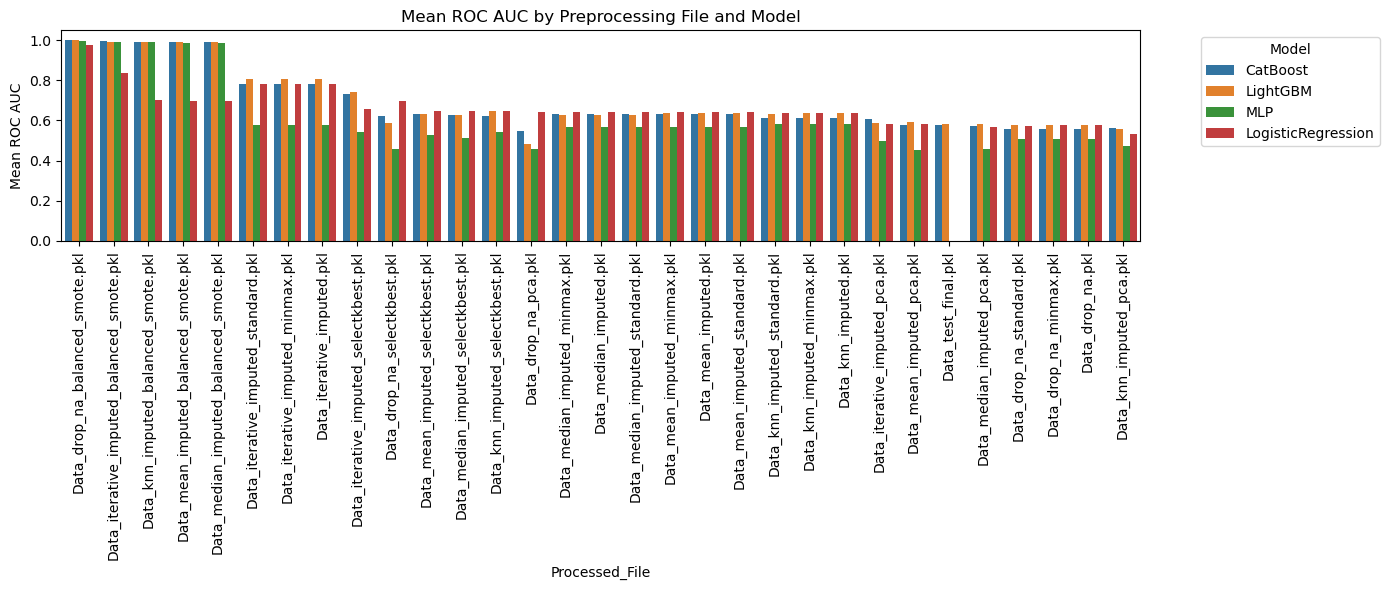

In [8]:
plt.figure(figsize=(14, 6))
sns.barplot(data=summary_df, x='Processed_File', y='mean_auc', hue='Model', ci=None)
plt.xticks(rotation=90)
plt.title("Mean ROC AUC by Preprocessing File and Model")
plt.ylabel("Mean ROC AUC")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "roc_auc_by_pipeline.png"), dpi=300)
plt.show()



### 3. Detect Overfitting Candidates

In [10]:
# Add a combined key for grouping
results_df['Pipeline'] = results_df['Processed_File'] + ' | ' + results_df['Model']

# Compute variation in metrics across folds
stability_df = results_df.groupby('Pipeline').agg(
    auc_std=('ROC AUC', 'std'),
    f1_std=('F1', 'std'),
    auc_range=('ROC AUC', lambda x: x.max() - x.min()),
    f1_range=('F1', lambda x: x.max() - x.min()),
    auc_mean=('ROC AUC', 'mean'),
    f1_mean=('F1', 'mean'),
    pipeline=('Pipeline', 'first')
).reset_index()

# Thresholds to flag potentially overfitted or unstable models
OVERFIT_AUC_STD_THRESHOLD = 0.02
OVERFIT_F1_STD_THRESHOLD = 0.03

stability_df['flag_overfit_auc'] = stability_df['auc_std'] > OVERFIT_AUC_STD_THRESHOLD
stability_df['flag_overfit_f1'] = stability_df['f1_std'] > OVERFIT_F1_STD_THRESHOLD
stability_df['flag_overfit'] = stability_df['flag_overfit_auc'] | stability_df['flag_overfit_f1']

# Show flagged models
overfit_candidates = stability_df[stability_df['flag_overfit']].sort_values(by='auc_mean', ascending=False)
print(f"\n🚨 {len(overfit_candidates)} Possibly overfitted or unstable pipelines:")
display(overfit_candidates[['Pipeline', 'auc_mean', 'f1_mean', 'auc_std', 'f1_std']])




🚨 54 Possibly overfitted or unstable pipelines:


,Pipeline,auc_mean,f1_mean,auc_std,f1_std
45,Data_iterative_imputed_standard.pkl | LightGBM,0.807088,0.221892,0.018394,0.033871
25,Data_iterative_imputed.pkl | LightGBM,0.807088,0.221892,0.018394,0.033871
33,Data_iterative_imputed_minmax.pkl | LightGBM,0.807088,0.221892,0.018394,0.033871
34,Data_iterative_imputed_minmax.pkl | LogisticRe...,0.782578,0.141496,0.021368,0.009142
46,Data_iterative_imputed_standard.pkl | Logistic...,0.782578,0.141496,0.021368,0.009142
26,Data_iterative_imputed.pkl | LogisticRegression,0.782578,0.141496,0.021368,0.009142
40,Data_iterative_imputed_selectkbest.pkl | CatBoost,0.730619,0.175531,0.026726,0.020335
18,Data_drop_na_selectkbest.pkl | LogisticRegression,0.696400,0.061550,0.138894,0.042157
14,Data_drop_na_pca.pkl | LogisticRegression,0.643311,0.041073,0.200885,0.015472
98,Data_median_imputed.pkl | LogisticRegression,0.642804,0.081133,0.020346,0.006101


### 4. Eliminate Suspicious Pipelines and Rank Stable Ones

In [12]:
valid_pipelines = stability_df[~stability_df['flag_overfit']]
top_ranked = valid_pipelines.sort_values(by='auc_mean', ascending=False).head(20)

print("\n🏆 Top-ranked stable pipelines:")
display(top_ranked[['Pipeline', 'auc_mean', 'f1_mean', 'auc_std', 'f1_std']])

# Save top-ranked list
top_ranked.to_csv(os.path.join(output_dir, "top_ranked_stable_pipelines.csv"), index=False)

# %%
# ### 5. Summary Table with Best Metrics per Pipeline

best_per_file_model = summary_df.sort_values(by='mean_auc', ascending=False).drop_duplicates(subset=['Processed_File', 'Model'])
final_ranking = best_per_file_model.sort_values(by='mean_auc', ascending=False)

print("\n📊 Final ranking of all unique (file, model) combinations:")
display(final_ranking.head(20))

# %%
# ### 6. Output Shortlisted Pipelines for Further Investigation

# Choose top N candidates (e.g., top 5)
SHORTLIST_TOP_N = 5
shortlisted = final_ranking.head(SHORTLIST_TOP_N).copy()
shortlisted['Pipeline'] = shortlisted['Processed_File'] + ' | ' + shortlisted['Model']

print(f"\n📌 Shortlisted {SHORTLIST_TOP_N} pipelines for further optimization:")
display(shortlisted[['Pipeline', 'mean_auc', 'mean_f1']])

# Save shortlist
shortlisted.to_csv(os.path.join(output_dir, "shortlisted_pipelines_for_tuning.csv"), index=False)


🏆 Top-ranked stable pipelines:


,Pipeline,auc_mean,f1_mean,auc_std,f1_std
4,Data_drop_na_balanced_smote.pkl | CatBoost,0.999943,0.996117,0.000066,0.004029
5,Data_drop_na_balanced_smote.pkl | LightGBM,0.999399,0.993270,0.000949,0.006587
7,Data_drop_na_balanced_smote.pkl | MLP,0.997507,0.984782,0.001723,0.003857
28,Data_iterative_imputed_balanced_smote.pkl | Ca...,0.994899,0.985448,0.000836,0.001110
29,Data_iterative_imputed_balanced_smote.pkl | Li...,0.994118,0.983921,0.001286,0.001159
31,Data_iterative_imputed_balanced_smote.pkl | MLP,0.993068,0.976546,0.001309,0.003014
52,Data_knn_imputed_balanced_smote.pkl | CatBoost,0.991086,0.983536,0.001298,0.001324
53,Data_knn_imputed_balanced_smote.pkl | LightGBM,0.990977,0.983673,0.001641,0.001379
77,Data_mean_imputed_balanced_smote.pkl | LightGBM,0.990914,0.983110,0.001451,0.001232
76,Data_mean_imputed_balanced_smote.pkl | CatBoost,0.990846,0.982938,0.001244,0.001580



📊 Final ranking of all unique (file, model) combinations:


,Processed_File,Model,mean_auc,std_auc,mean_f1,std_f1,count
4,Data_drop_na_balanced_smote.pkl,CatBoost,0.999943,0.000066,0.996117,0.004029,5
5,Data_drop_na_balanced_smote.pkl,LightGBM,0.999399,0.000949,0.993270,0.006587,5
7,Data_drop_na_balanced_smote.pkl,MLP,0.997507,0.001723,0.984782,0.003857,5
28,Data_iterative_imputed_balanced_smote.pkl,CatBoost,0.994899,0.000836,0.985448,0.001110,5
29,Data_iterative_imputed_balanced_smote.pkl,LightGBM,0.994118,0.001286,0.983921,0.001159,5
31,Data_iterative_imputed_balanced_smote.pkl,MLP,0.993068,0.001309,0.976546,0.003014,5
52,Data_knn_imputed_balanced_smote.pkl,CatBoost,0.991086,0.001298,0.983536,0.001324,5
53,Data_knn_imputed_balanced_smote.pkl,LightGBM,0.990977,0.001641,0.983673,0.001379,5
77,Data_mean_imputed_balanced_smote.pkl,LightGBM,0.990914,0.001451,0.983110,0.001232,5
76,Data_mean_imputed_balanced_smote.pkl,CatBoost,0.990846,0.001244,0.982938,0.001580,5



📌 Shortlisted 5 pipelines for further optimization:


,Pipeline,mean_auc,mean_f1
4,Data_drop_na_balanced_smote.pkl | CatBoost,0.999943,0.996117
5,Data_drop_na_balanced_smote.pkl | LightGBM,0.999399,0.993270
7,Data_drop_na_balanced_smote.pkl | MLP,0.997507,0.984782
28,Data_iterative_imputed_balanced_smote.pkl | Ca...,0.994899,0.985448
29,Data_iterative_imputed_balanced_smote.pkl | Li...,0.994118,0.983921
